In [13]:
from pathlib import Path
from ultralytics import YOLO

MODEL_PATH = Path("..\\runs\\classify\\runs\\cat_or_dog\\weights\\best.pt")

print("Arquivo existe?", MODEL_PATH.exists())

model = YOLO(MODEL_PATH)

print("Modelo carregado com sucesso!")

Arquivo existe? True
Modelo carregado com sucesso!


In [10]:
# Caminho da imagem
image_path = "../dataset/test/cats/9839.jpg"

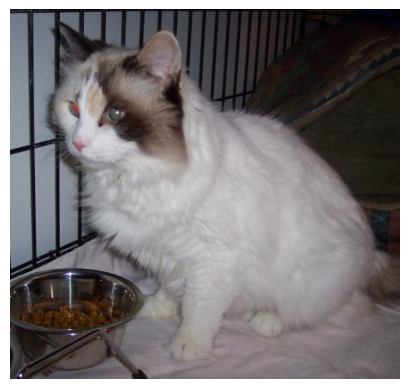

In [12]:
import cv2
import matplotlib.pyplot as plt

# Lê a imagem com OpenCV
img_bgr = cv2.imread(image_path)

# Converte de BGR (OpenCV) para RGB (matplotlib/Jupyter)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Exibe no Jupyter Notebook
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [14]:
results = model(image_path, verbose=False)

# Índice da classe prevista
pred_idx = results[0].probs.top1

# Nome da classe prevista
pred_label = results[0].names[pred_idx]

# Confiança da previsão
confidence = results[0].probs.top1conf.item()

print(f"Classe prevista: {pred_label}")
print(f"Confiança: {confidence:.2%}")

Classe prevista: cats
Confiança: 95.61%


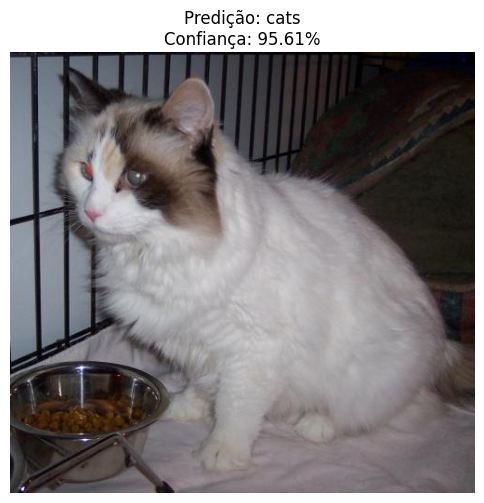

In [15]:
img = Image.open(image_path)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Predição: {pred_label}\n"
    f"Confiança: {confidence:.2%}"
)
plt.show()

In [16]:
def predict_image(image_path):
    results = model(image_path, verbose=False)

    pred_idx = results[0].probs.top1
    pred_label = results[0].names[pred_idx]
    confidence = results[0].probs.top1conf.item()

    img = Image.open(image_path)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Predição: {pred_label}\n"
        f"Confiança: {confidence:.2%}"
    )
    plt.show()

    print(f"Classe prevista: {pred_label}")
    print(f"Confiança: {confidence:.2%}")

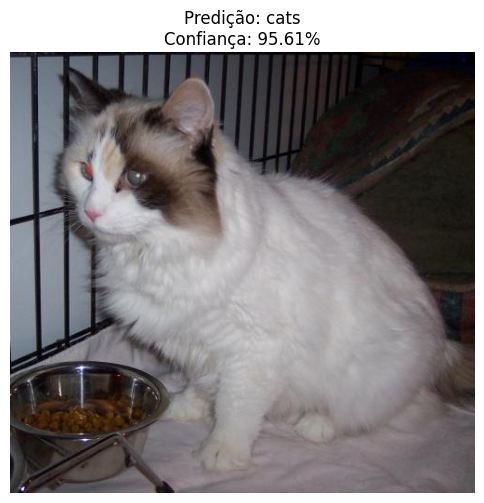

Classe prevista: cats
Confiança: 95.61%


In [17]:
predict_image("../dataset/test/cats/9839.jpg")